Vectorizing TEST: 100%|██████████| 3523/3523 [02:46<00:00, 21.19it/s]


🚀 Training stacking model (DEFAULT parameters)...
✅ Training completed

=== FINAL TEST EVALUATION ===
Accuracy : 0.8836219131422084
Precision: 0.6760752688172043
Recall   : 0.7485119047619048
F1-score : 0.71045197740113
AUC      : 0.901556053849109

=== CLASSIFICATION REPORT (PER LABEL) ===
              precision    recall  f1-score   support

     Label 0     0.9392    0.9155    0.9272      2851
     Label 1     0.6761    0.7485    0.7105       672

    accuracy                         0.8836      3523
   macro avg     0.8076    0.8320    0.8188      3523
weighted avg     0.8890    0.8836    0.8858      3523

=== CONFUSION MATRIX ===
[[2610  241]
 [ 169  503]]


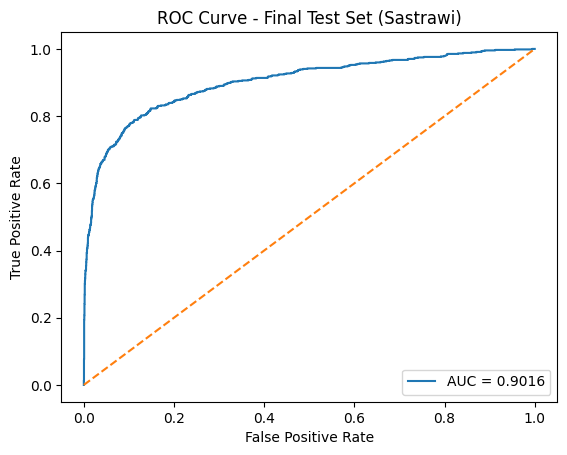

In [1]:
# =====================================================
# STACKING ENSEMBLE FASTTEXT INDONESIA (SASTRAWI VERSION)
# =====================================================

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

# 🔥 SASTRAWI
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import gensim.downloader as api

# =====================================================
# LOAD FASTTEXT INDONESIA
# =====================================================
fasttext = api.load('fasttext-wiki-news-subwords-300')

# =====================================================
# SASTRAWI SETUP
# =====================================================

# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopwords
stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

# Stopwords yang ingin dilindungi (tidak dihapus)
protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}

final_stopwords = stop_words_id - protected_stopwords

# =====================================================
# PREPROCESSING
# =====================================================

def preprocess_text(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()  # lebih cepat dari word_tokenize

    # Stopword removal
    tokens = [t for t in tokens if t not in final_stopwords]

    # Stemming Sastrawi
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens


# =====================================================
# FASTTEXT VECTOR
# =====================================================

def document_vector(tokens, model, vector_size=300):
    vectors = [model[w] for w in tokens if w in model]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)


def vectorize_series_with_progress(text_series, desc="Vectorizing"):
    vectors = []

    for text in tqdm(text_series, desc=desc):
        if not isinstance(text, str):
            text = ""

        tokens = preprocess_text(text)
        vectors.append(document_vector(tokens, fasttext))

    return np.vstack(vectors)


# =====================================================
# STACKING MODEL (DEFAULT PARAMS)
# =====================================================

def build_stacking_model_default():
    base_learners = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier()),
        ('svm', SVC(probability=True))  # default kernel='rbf'
    ]

    meta_learner = LogisticRegression(max_iter=1000)

    return StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1
    )


# =====================================================
# LOAD DATA
# =====================================================

dataset_a = pd.read_csv('smote_100.csv')
dataset_b = pd.read_csv('data_20.csv')

X_a = dataset_a['Text']
y_a = dataset_a['label']

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_a, y_a,
    test_size=0.125,
    random_state=42,
    stratify=y_a
)

# =====================================================
# VECTORIZATION
# =====================================================

X_train = vectorize_series_with_progress(X_train_text, desc="Vectorizing TRAIN")
X_val   = vectorize_series_with_progress(X_val_text, desc="Vectorizing VAL")
X_test  = vectorize_series_with_progress(dataset_b['Text'], desc="Vectorizing TEST")

y_test = dataset_b['label']

# =====================================================
# TRAINING
# =====================================================

final_model = build_stacking_model_default()

X_final = np.vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

print("🚀 Training stacking model (DEFAULT parameters)...")
final_model.fit(X_final, y_final)
print("✅ Training completed")

# =====================================================
# EVALUATION
# =====================================================

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print('\n=== FINAL TEST EVALUATION ===')
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))
print('AUC      :', roc_auc_score(y_test, y_proba))

print("\n=== CLASSIFICATION REPORT (PER LABEL) ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Label 0", "Label 1"],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set (Sastrawi)")
plt.legend(loc="lower right")
plt.show()